In [5]:
pip install  missingno

Note: you may need to restart the kernel to use updated packages.


In [6]:
# ============================================================
# Q1 — Missingness Profiling and Correlation Heatmap
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Create example DataFrame with mixed missingness
# ------------------------------------------------------------

df = pd.DataFrame({
    "Age": [25, 30, np.nan, 40, 50, np.nan, 60, 70, 35, 45],
    
    "Blood_Pressure": [
        120, np.nan, 130, 140, np.nan,
        150, 160, 170, np.nan, 135
    ],
    
    "Cholesterol": [
        180, 190, 200, np.nan, 220,
        230, np.nan, 250, 210, np.nan
    ],
    
    "Glucose": [
        90, 100, np.nan, 120, 130,
        np.nan, 150, 160, np.nan, 110
    ],
    
    "Weight": [
        65, 70, np.nan, 80, 85,
        90, 95, np.nan, 75, 82
    ],
    
    "Outcome": [
        0, 1, 0, 1, 0,
        1, 0, 1, 0, 1
    ]
})

print("Original DataFrame:")
display(df)




Original DataFrame:


,Age,Blood_Pressure,Cholesterol,Glucose,Weight,Outcome
0,25.0,120.0,180.0,90.0,65.0,0
1,30.0,NaN,190.0,100.0,70.0,1
2,NaN,130.0,200.0,NaN,NaN,0
3,40.0,140.0,NaN,120.0,80.0,1
4,50.0,NaN,220.0,130.0,85.0,0
5,NaN,150.0,230.0,NaN,90.0,1
6,60.0,160.0,NaN,150.0,95.0,0
7,70.0,170.0,250.0,160.0,NaN,1
8,35.0,NaN,210.0,NaN,75.0,0
9,45.0,135.0,NaN,110.0,82.0,1


In [7]:
# ------------------------------------------------------------
# 2. Missing count per column
# ------------------------------------------------------------

missing_count = df.isnull().sum()

print("\nMissing values per column:")
print(missing_count)


Missing values per column:
Age               2
Blood_Pressure    3
Cholesterol       3
Glucose           3
Weight            2
Outcome           0
dtype: int64


In [8]:
# ------------------------------------------------------------
# 3. Missing percentage per column
# ------------------------------------------------------------

missing_percentage = (
    df.isnull()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

print("\nMissing percentage per column:")
print(missing_percentage)


# ------------------------------------------------------------
# 4. Create a summary table
# ------------------------------------------------------------

missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": df.isnull().mean() * 100
})

print("\nMissingness Summary:")
display(missing_summary)



Missing percentage per column:
Blood_Pressure    30.0
Cholesterol       30.0
Glucose           30.0
Age               20.0
Weight            20.0
Outcome            0.0
dtype: float64

Missingness Summary:


,Missing Count,Missing Percentage
Age,2,20.0
Blood_Pressure,3,30.0
Cholesterol,3,30.0
Glucose,3,30.0
Weight,2,20.0
Outcome,0,0.0


In [9]:

# ------------------------------------------------------------
# 5. Create missingness indicators
#
# 1 = value is missing
# 0 = value is observed
# ------------------------------------------------------------

missing_indicators = df.isnull().astype(int)

print("\nMissingness Indicators:")
display(missing_indicators)


# ------------------------------------------------------------
# 6. Correlation between missingness indicators
# ------------------------------------------------------------

missing_corr = missing_indicators.corr()

print("\nMissingness Correlation Matrix:")
display(missing_corr)


Missingness Indicators:


,Age,Blood_Pressure,Cholesterol,Glucose,Weight,Outcome
0,0,0,0,0,0,0
1,0,1,0,0,0,0
2,1,0,0,1,1,0
3,0,0,1,0,0,0
4,0,1,0,0,0,0
5,1,0,0,1,0,0
6,0,0,1,0,0,0
7,0,0,0,0,1,0
8,0,1,0,1,0,0
9,0,0,1,0,0,0



Missingness Correlation Matrix:


,Age,Blood_Pressure,Cholesterol,Glucose,Weight,Outcome
Age,1.000000,-0.327327,-0.327327,0.763763,0.375000,NaN
Blood_Pressure,-0.327327,1.000000,-0.428571,0.047619,-0.327327,NaN
Cholesterol,-0.327327,-0.428571,1.000000,-0.428571,-0.327327,NaN
Glucose,0.763763,0.047619,-0.428571,1.000000,0.218218,NaN
Weight,0.375000,-0.327327,-0.327327,0.218218,1.000000,NaN
Outcome,NaN,NaN,NaN,NaN,NaN,NaN


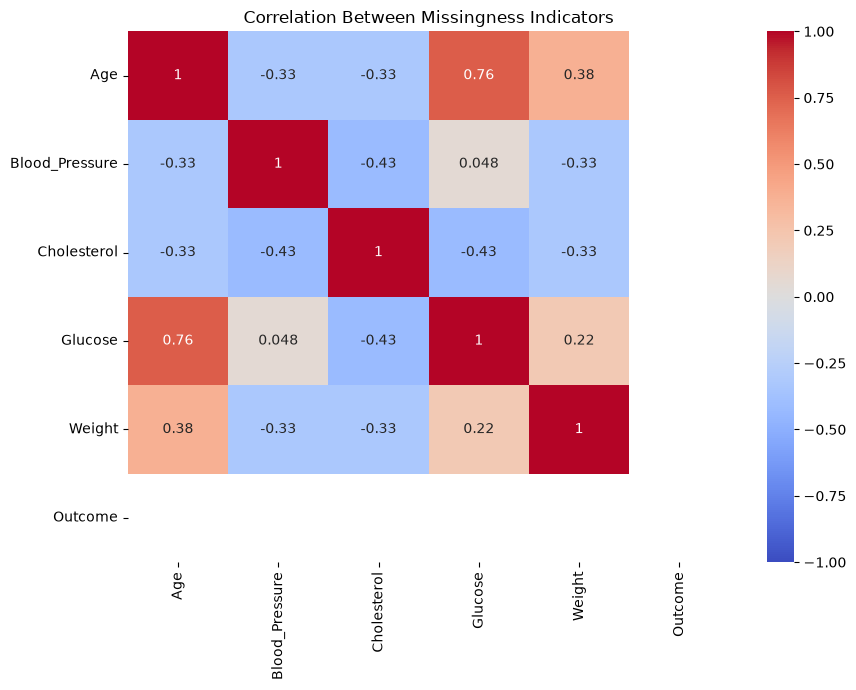

In [10]:
# ------------------------------------------------------------
# 7. Plot missingness correlation heatmap
# ------------------------------------------------------------

plt.figure(figsize=(9, 7))

sns.heatmap(
    missing_corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0
)

plt.title("Correlation Between Missingness Indicators")
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

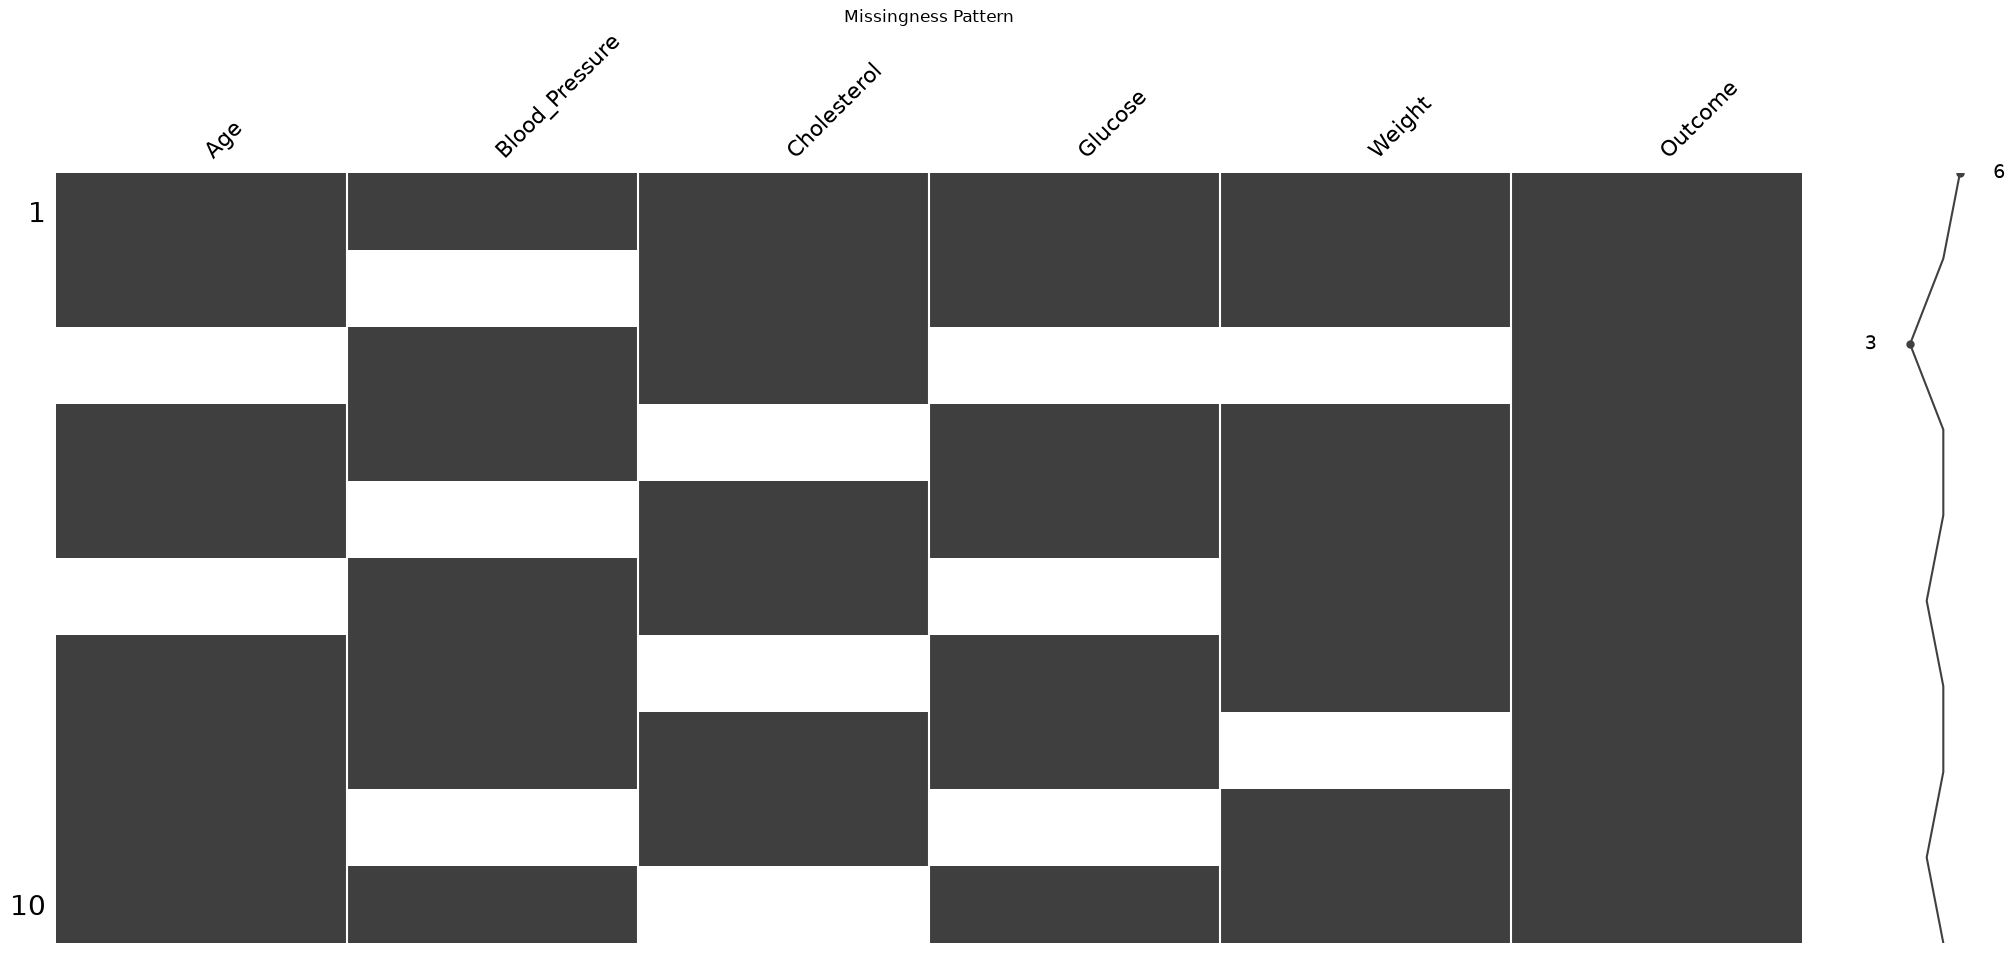

<Figure size 800x600 with 0 Axes>

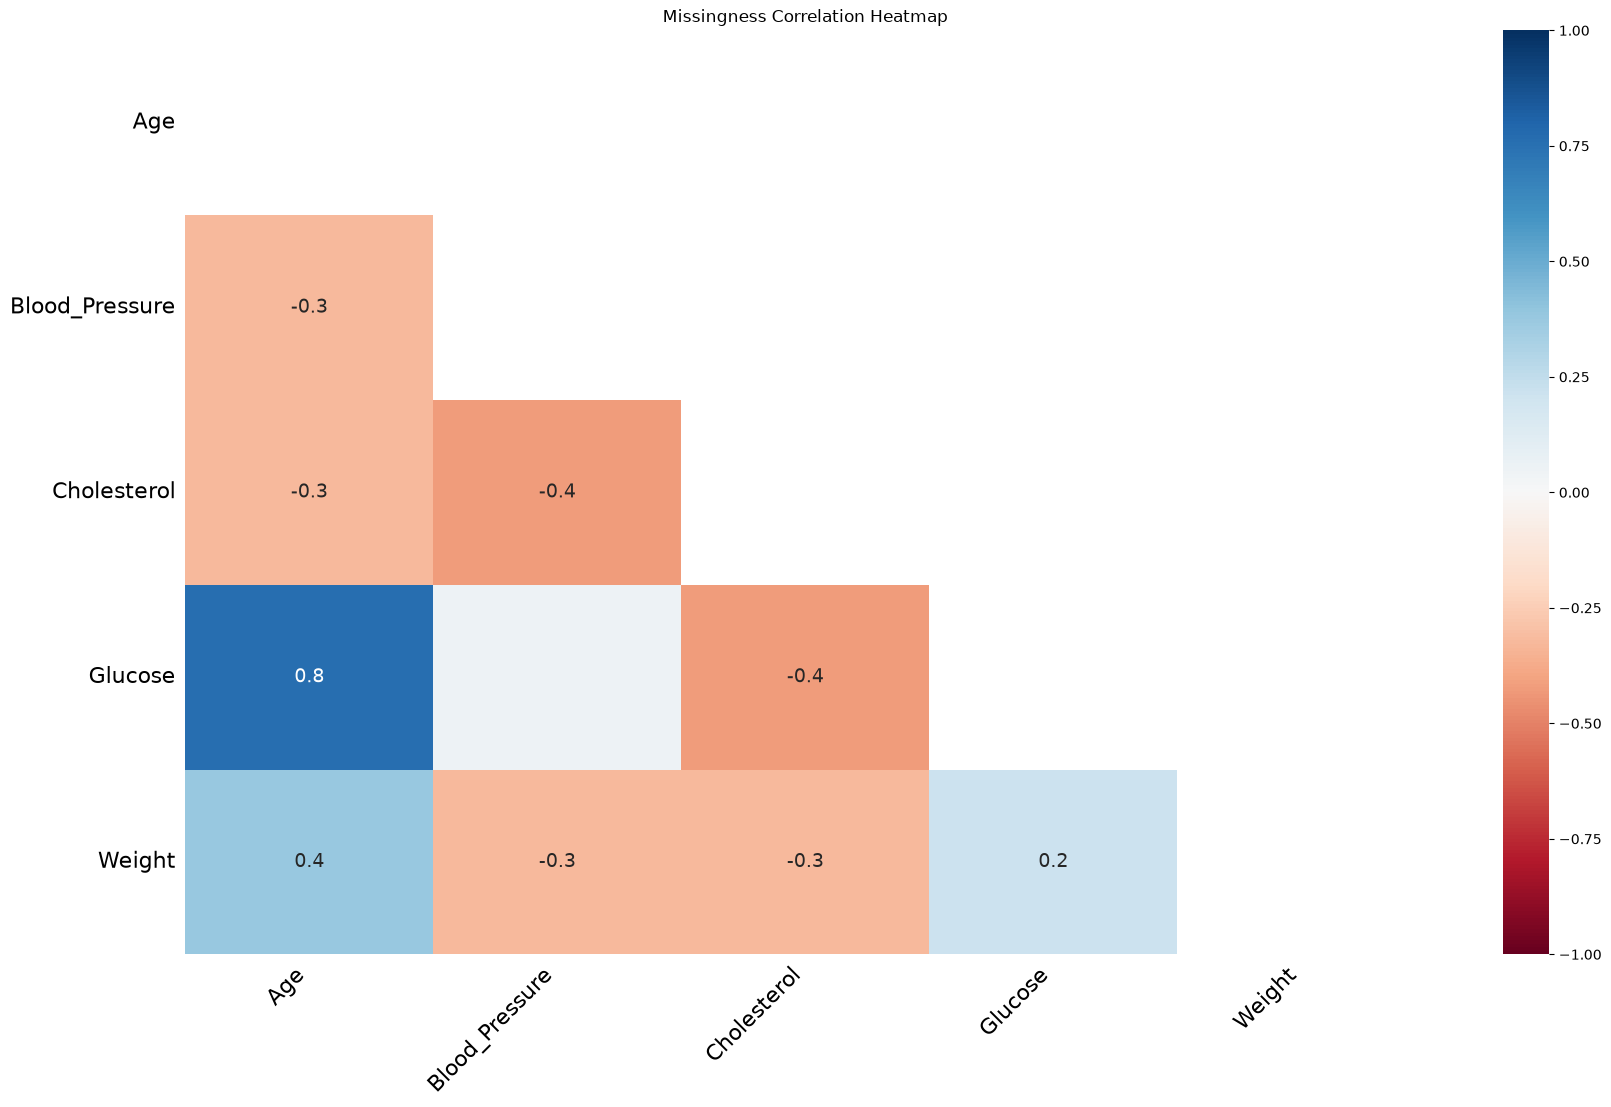

In [11]:
# ------------------------------------------------------------
# 8. Install missingno if necessary
# ------------------------------------------------------------

# Uncomment if missingno is not installed:
# !pip install missingno


# ------------------------------------------------------------
# 9. Missingno visualization
# ------------------------------------------------------------

import missingno as msno

plt.figure(figsize=(10, 5))

msno.matrix(df)

plt.title("Missingness Pattern")
plt.show()


# ------------------------------------------------------------
# 10. Missingno heatmap
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

msno.heatmap(df)

plt.title("Missingness Correlation Heatmap")
plt.show()